<a href="https://colab.research.google.com/github/Eddythemachine/intro_to_cnn/blob/main/training_minst_fashion_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trying out CNN
### Using MINST fashion dataset

# LIB IMPORT

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

# Data Import

In [2]:
train = pd.read_csv("/content/sample_data/mnist_test.csv")
len(train)

9999

## Visualising Our Data

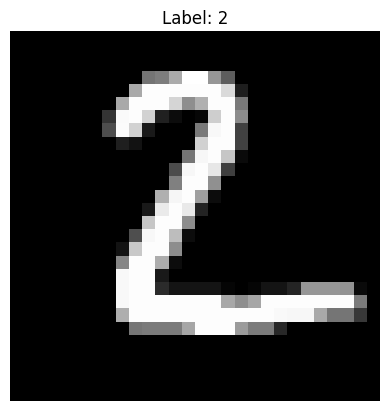

In [3]:
image_data = train.iloc[0, 1:].values.reshape(28, 28)
label = train.iloc[0, 0]

plt.imshow(image_data, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

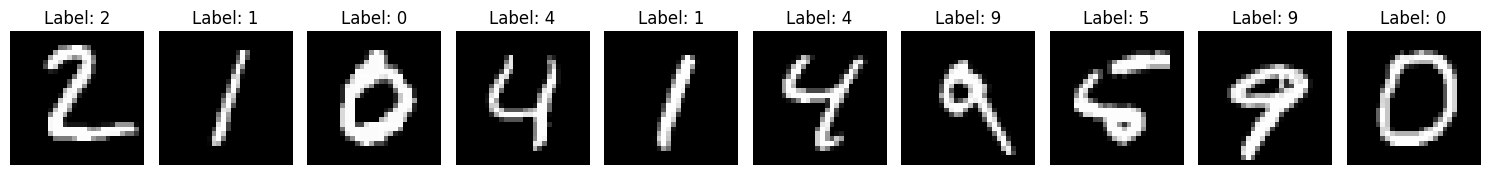

In [4]:
num_images_to_display = 10

plt.figure(figsize=(15, 5)) # Adjusted figure size for 10 images
for i in range(num_images_to_display):
    image_data = train.iloc[i, 1:].values.reshape(28, 28)
    label = train.iloc[i, 0]

    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(image_data, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
X = train.iloc[:, 1:].values.astype("float32")
y = train.iloc[:, 0].values.astype("int64")

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (9999, 784)
Shape of y: (9999,)


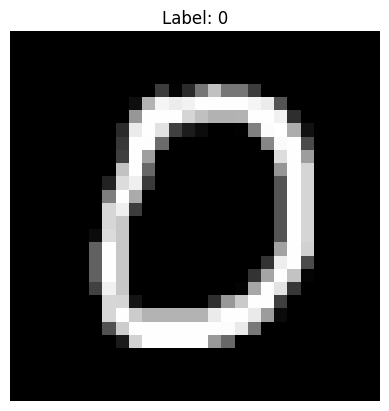

In [6]:
image_index = 9 # For the 10th image (0-indexed)
image_data_to_plot = X[image_index].reshape(28, 28)
label_to_plot = y[image_index]

plt.imshow(image_data_to_plot, cmap='gray')
plt.title(f"Label: {label_to_plot}")
plt.axis('off')
plt.show()

# Preprocessing Data

In [7]:
X /= 255.0
print(X.max(), X.min())

1.0 0.0


In [8]:
X_all,X_test,y_all,y_test = train_test_split(X,y, random_state=42, test_size=0.2)
X_train,X_val,y_train,y_val = train_test_split(X_all,y_all, random_state=42, test_size=0.2)

# Reshape X_train and X_val for CNN input
X_train = X_train.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (6399, 28, 28, 1)
Shape of X_val: (1600, 28, 28, 1)
Shape of y_train: (6399,)
Shape of y_val: (1600,)


In [9]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

In [10]:
BATCH_SIZE = 32
BUFFER_SIZE = len(X_train) # Shuffles the entire dataset if buffer_size >= num_elements

train_dataset = train_dataset.shuffle(buffer_size=BUFFER_SIZE).batch(BATCH_SIZE)

In [11]:
for features, labels in train_dataset.take(1):
    input_shape = features.shape[1:]
    print(f"Input shape of the dataset: {input_shape}")

Input shape of the dataset: (28, 28, 1)


# Model Building

In [12]:
model_1 = tf.keras.Sequential([
    # Input Layer
    tf.keras.layers.Conv2D(32,(3,3), activation="relu", input_shape=(28, 28, 1)), # Corrected input_shape and added comma
    tf.keras.layers.MaxPooling2D((2,2)),

    # Second Layer
    tf.keras.layers.Conv2D(64,(3,3), activation="relu"), # Added comma
    tf.keras.layers.MaxPooling2D((2,2)),

    # Flatten and Classify
    tf.keras.layers.Flatten(), # Added comma
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax') # 10 classes
])

model_1.compile(tf.keras.optimizers.Adam(learning_rate=0.003), # Changed 'model' to 'model_1'
                loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# 3. View Architecture
model_1.summary() # Changed 'model' to 'model_1'

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_1 = model_1.fit(
    train_dataset,
    validation_data=(X_val,y_val),
    epochs=20,
    verbose=1
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9920 - loss: 0.0252 - val_accuracy: 0.9906 - val_loss: 0.0371
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9913 - loss: 0.0228 - val_accuracy: 0.9844 - val_loss: 0.0537
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9895 - loss: 0.0302 - val_accuracy: 0.9856 - val_loss: 0.0630
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9944 - loss: 0.0199 - val_accuracy: 0.9837 - val_loss: 0.0639
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9897 - loss: 0.0337 - val_accuracy: 0.9831 - val_loss: 0.0717
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9944 - loss: 0.0150 - val_accuracy: 0.9825 - val_loss: 0.1059
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9907 - loss: 0.0332 - val_accuracy: 0.9856 - val_loss: 0.0766
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9925 - loss: 0.0247 - val_accuracy: 0.

# Evaluate Model

In [16]:
test_loss,test_acc = model_1.evaluate(X_test,y_test, verbose=1)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9900 - loss: 0.0857

Test accuracy: 0.9850
Test loss: 0.1122


In [18]:
y_pred = model_1.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [20]:
predicted_classes = np.argmax(y_pred, axis=1)
predicted_classes

array([4, 7, 9, ..., 2, 7, 8])

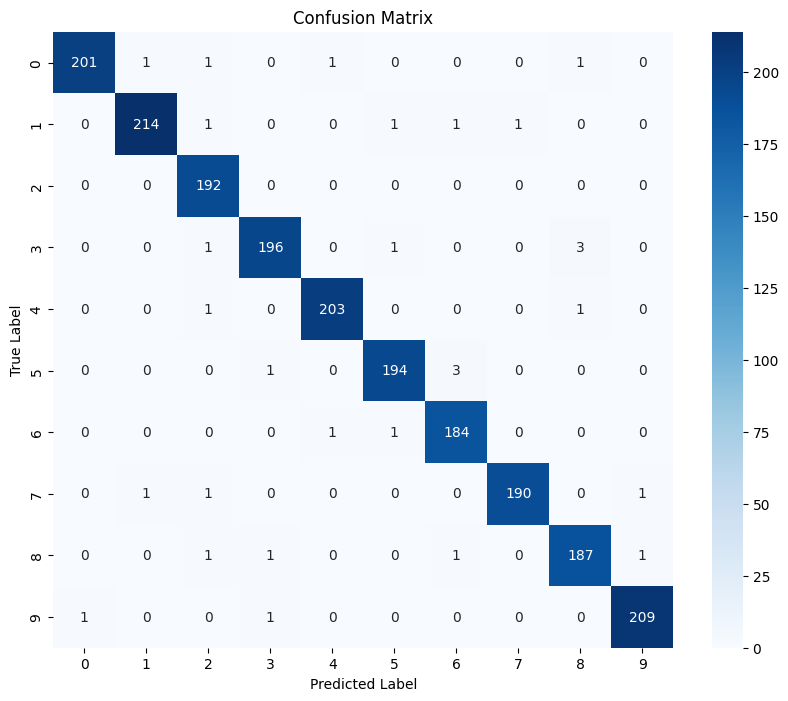

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()